# Comparaison de deux processus dans la modélisation du cours de l'or
## 1) Introduction 

Ce notebook a pour objectif d'examiner le comportement du cours de l'or. Pourquoi s'y intéresser particulièrement ? Tout simplement pour son ambiguïté. En effet, l'or est à cheval entre un actif d'investissement, comme peut l'être une action, et une commodity, comme le pétrole, qui a pour but d'être consommé. Ces deux classes se comportent différemment. Les actifs d'investissement ont tendance à suivre (approximativement bien sûr) un processus que l'on nomme Geometrical Brownian Motion (GBM) et qui obéit à cette équation stochastique :
$$ dX_t = \mu X_t dt + \sigma dW_t, \quad X_0 $$
Tandis que les commodities se comportent en suivant un processus dit "mean reverting", appelé Ornstein-Uhlenbeck (OU) qui obéit à l'équation stochastique suivante : 
$$ dY_t = \kappa (\theta - Y_t)dt + \sigma dW_t, \quad Y_0$$

Où $(W_t)_{t \geq 0}$ est un processus de Wiener, aussi appelé mouvement Brownien. \
Un GBM a une formule analytique :
$$ X_t = X_0 \exp{((\mu - \frac{\sigma^2}{2})t + \sigma W_t)} $$

Tandis qu'un OU n'a pas de formule explicite, mais suit une loi normale : 
$$Y_t = Y_0e^{-\kappa t} + \theta (1-e^{-\kappa t}) + \sigma e^{-\kappa t} \int_0^te^{\kappa s}dW_s $$

On constate donc que le GBM ne dépend que de $W_t$ à l'instant $t$, tandis que le OU dépend de tous les $W_s$, pour $s \leq t$, en raison de l'intégrale. \
De par les propriétés d'accroissement indépendant d'un processus de Wiener, les rendements logarithmiques d'un GBM ont une autocorrélation nulle, ce qui n'est pas le cas pour un OU, dont les rendements ont une autocorrélation négative pour les premiers lags.

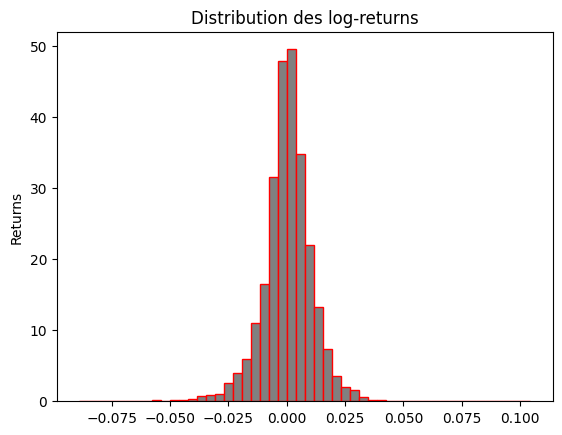

In [335]:
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller, acf
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt
import random
from statsmodels.tsa.stattools import adfuller


prices = pd.read_csv("GOLD_USD - Données Historiques.csv")   #Les données s'étalent sur 19 ans
prices = prices["Dernier"]                                  #On ne garde que les prix de fermeture
prices = prices.iloc[::-1].reset_index(drop=True)           #On retourne la liste qui était dans l'ordre inverse au temps


prices = (prices                                            #On reformate un peu les données qui étaient des chaînes de caractères
          .str.replace('.', '', regex=False)   
        .str.replace(',', '.', regex=False)
        .astype(float)
    )


returns = [np.log(prices[k+1]) - np.log(prices[k]) for k in range (0, len(prices) - 1)]  #on obtient désormais les log-returns


GBM = [1]                                                 #On crée aussi un GBM pour voir comment il va réagir aux tests
mu = 0.5
sigma = 0.2
dt = 1/252

for k in range(1,len(prices)) :
    GBM.append(GBM[k-1]*np.exp((mu - sigma**2/2)*dt + sigma*np.sqrt(dt)*random.gauss(0,1)))

OU = [1]                                                    #Et un OU
kappa = 2
theta = 1
for k in range(1,len(prices)) :
    OU.append(OU[k-1] + kappa*(theta - OU[k-1])*dt + np.sqrt(dt)*sigma*random.gauss(0,1))

returns_GBM = [np.log(GBM[k+1]) - np.log(GBM[k]) for k in range (0, len(GBM) - 1)]
returns_OU = [(OU[k+1] - OU[k])/OU[k] for k in range (0, len(GBM) - 1)]

#Impossible de prendre les log-returns d'un OU car il peut être négatif.

plt.hist(returns, color = 'grey', edgecolor = 'red', density = True, bins = 50)
plt.xlabel('')
plt.ylabel('Returns')
plt.title('Distribution des log-returns')
plt.show()




## 2) Test ACF

Désormais, nous avons une liste claire des log-returns. Nous pouvons maintenant appliquer le premier test, celui de  l'autocorrélation. Pour rappel, l'autocorrélation est une fonction qui à un entier $k$ associe :
$$ ACF(k) = \frac{Cov(X_t,X_{t+k})}{\sigma_t \sigma_{t+k}} \in [-1,1] $$

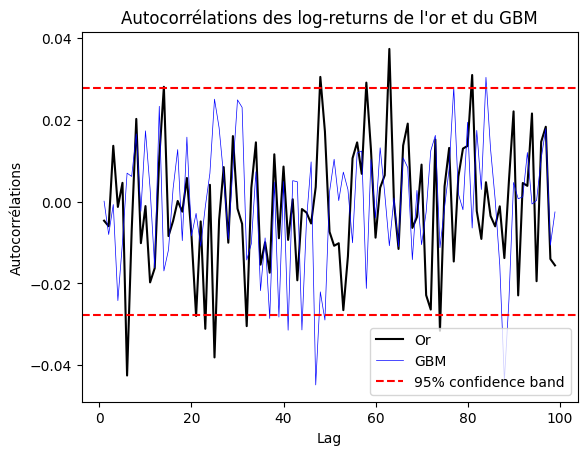

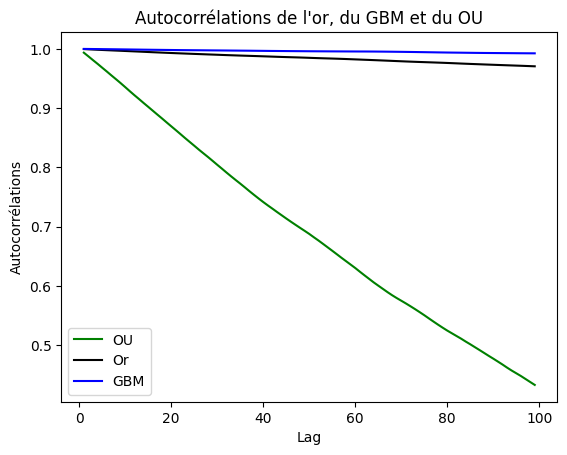

Moyenne des autocorrélations des log-returns de l'or = -0.0012555837623196644


In [336]:
def acf(k, list) :
    res = []
    for i in range(0,len(list)-k) :
        res.append(list[i]*list[i+k])
    x = list[:len(list)-k]
    y = list[k:]
    sigma_t = np.std(x)
    sigma_k = np.std(y)
    return ((np.mean(res) - np.mean(x)*np.mean(y))/(sigma_t*sigma_k))

ACF_returns = [acf(k, returns) for k in range(1,100)]
ACF_GBM_returns = [acf(k, returns_GBM) for k in range(1,100)]
confidence = 1.96 / np.sqrt(len(returns))
X = list(range(1, 100))
plt.plot(X, ACF_returns, color = 'black', label = 'Or')
plt.plot(X, ACF_GBM_returns, color = 'blue', lw = 0.5, label = 'GBM')
plt.title("Autocorrélations des log-returns de l'or et du GBM")
plt.ylabel('Autocorrélations')
plt.xlabel('Lag')
plt.axhline(y=confidence, color='red', linestyle='--', label='95% confidence band')
plt.axhline(y=-confidence, color='red', linestyle='--')
plt.legend()
plt.show()

ACF_OU = [acf(k, OU) for k in range(1,100)]
ACF_prices = [acf(k, prices) for k in range(1,100)]
ACF_GBM = [acf(k, GBM) for k in range(1,100)]

plt.plot(X, ACF_OU, color = 'green', label = 'OU')
plt.ylabel('Autocorrélations')
plt.xlabel('Lag')
plt.plot(X, ACF_prices, color = 'black', label ='Or')
plt.title("Autocorrélations de l'or, du GBM et du OU")
plt.plot(X, ACF_GBM, color = 'blue', label ='GBM')
plt.legend()
plt.show()

print(f"Moyenne des autocorrélations des log-returns de l'or =", float(np.mean(ACF_returns)))



Ce premier test fait pencher la balance du côté du GBM. En effet, l'autocorrélation des log-returns est proche de $0$, et semble répartie aléatoirement autour de $0$. On a ajouté les bandes de l'intervalle de confiance à $95$%, c'est à dire que $95$% des autocorrélations devraient être dans cet intervalle. En l'occurrence, 11 d'entre elles sont en dehors, ce qui, même sans coller parfaitement à un GBM, reste relativement proche. De manière un peu plus intuitive, on constate que le comportement des autocorrélations pour les log-returns du GBM et de l'or sont similaires.\
Les résultats sur l'autocorrélation des prix bruts laissent aussi penser à une distribution proche d'un GBM.

## 3) Test ADF


Nous avons extrait tout ce que nous pouvions du test d'autocorrélation. Désormais, appliquons un second test, que l'on appelle test Augmenté de Dickey-Fuller (ADF). Il permet de vérifier si une série temporelle a une racine unitaire, c'est-à-dire si ses propriétés statistiques (moyenne, variance) sont constantes dans le temps. Un processus OU n'en a pas, car il est stationnaire, tandis qu'un GBM devrait en avoir une, puisqu'il dérive indéfiniment.\n
Petit topo sur le test ADF : il teste l'hypothèse suivante :
$$ H_0 : \text{la série temporelle a une racine unitaire} \implies \text{la série est non-stationnaire} $$
Ce test renvoie un nombre $\beta$, plus $\beta$ est négatif, plus on rejette l'hypothèse $H_0$. 

In [337]:
result_GBM = adfuller(GBM)
print('GBM')
print(f"Statistique ADF : {result_GBM[0]:.4f}")
print(f"P-value : {result_GBM[1]:.4f}")
print("Valeurs critiques :", {k: float(v) for k, v in result_GBM[4].items()})
print('')

result_OU = adfuller(OU)
print('OU')
print(f"Statistique ADF : {result_OU[0]:.4f}")
print(f"P-value : {result_OU[1]:.4f}")
print("Valeurs critiques :", {k: float(v) for k, v in result_OU[4].items()})
print('')

result = adfuller(prices)
print('Prices or')
print(f"Statistique ADF : {result[0]:.4f}")
print(f"P-value : {result[1]:.4f}")
print("Valeurs critiques :", {k: float(v) for k, v in result[4].items()})
print('')

result_returns = adfuller(returns)
print('Returns or')
print(f"Statistique ADF : {result_returns[0]:.4f}")
print(f"P-value : {result_returns[1]:.4f}")
print("Valeurs critiques :", {k: float(v) for k, v in result_returns[4].items()})

GBM
Statistique ADF : 8.9815
P-value : 1.0000
Valeurs critiques : {'1%': -3.4316672302646283, '5%': -2.8621220724882153, '10%': -2.5670798380375506}

OU
Statistique ADF : -3.9951
P-value : 0.0014
Valeurs critiques : {'1%': -3.431658793968827, '5%': -2.862118345383404, '10%': -2.567077853953267}

Prices or
Statistique ADF : -1.0531
P-value : 0.7334
Valeurs critiques : {'1%': -3.431658793968827, '5%': -2.862118345383404, '10%': -2.567077853953267}

Returns or
Statistique ADF : -29.8669
P-value : 0.0000
Valeurs critiques : {'1%': -3.431660367533127, '5%': -2.862119040575461, '10%': -2.5670782240311683}


Tout d'abord, on constate que le test renvoie des résultats très satisfaisants pour les processus connus. En effet, pour le GBM, la statistique ADF est positive, avec une p-value très proche de $1$, c'est à dire que l'on adopte presque l'hypothèse $H_0$ à $100$%. Le test ADF confirme qu'un GBM n'est pas stationnaire.\
A l'inverse, le test rejette totalement l'hypothèse pour un OU, donc on est assurés qu'un OU est stationnaire. 

Les résultats sous-entendent une fois de plus une distribution en GBM. Une p-value de $0,7334$ suggère avec une certaine certitude un comportement non-stationnaire. 

La balance penche de plus en plus du côté d'un comportement en actif d'investissement ! 

## 4) Test du variance-ratio

Il nous reste un dernier test à effectuer. Le test de ratio de variance de Lo-MacKinlay. Si une série suit un GBM, la variance des rendements croît linéairement avec l'horizon : 
$$\mathbb{V}(r_t^{(q)})=q\mathbb{V}(r_t), \quad r_t^{(q)} = \log(\frac{P_{t+q}}{P_t}) $$
donc le ratio vaut $1$.\
En revanche, pour un processus mean-reverting, la variance croît moins vite que $q$. On applique donc le test de Lo-MacKinlay, qui calcule
$$ VR(q) = \frac{\mathbb{V}(r_t^{(q)})}{q\mathbb{V}(r_t)}$$

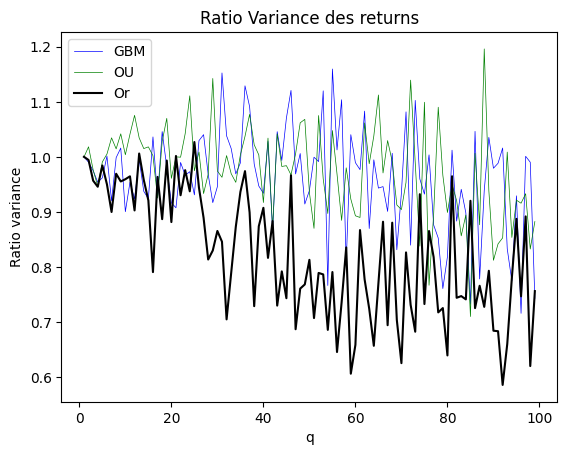

In [338]:
def variance_ratio(q, list) :
    var = np.var(list)
    list_q = []
    for k in range(0,len(list)//q - 1) :
        list_q.append(sum(list[k*q:(k+1)*q]))
    return(np.var(list_q)/(q*var))

VR_GBM = [variance_ratio(q,returns_GBM) for q in range(1,100)]
VR_OU = [variance_ratio(q,returns_OU) for q in range(1,100)]
VR_or = [variance_ratio(q,returns) for q in range(1,100)]



plt.plot(X, VR_GBM, color = 'blue', label = 'GBM', lw = 0.5)
plt.plot(X, VR_OU, color = 'green', label = 'OU', lw = 0.5)
plt.plot(X, VR_or, color = 'black', label = 'Or')
plt.title('Ratio Variance des returns')
plt.xlabel('q')
plt.ylabel('Ratio variance')
plt.legend()
plt.show()

En fonction des simulations, avec des trajectoires différentes pour le GBM et le OU, les résultats varient. Nous allons donc réaliser ce test avec $50$ simulations de chaque et faire une moyenne pour tracer les courbes variance-ratio du GBM et du OU.

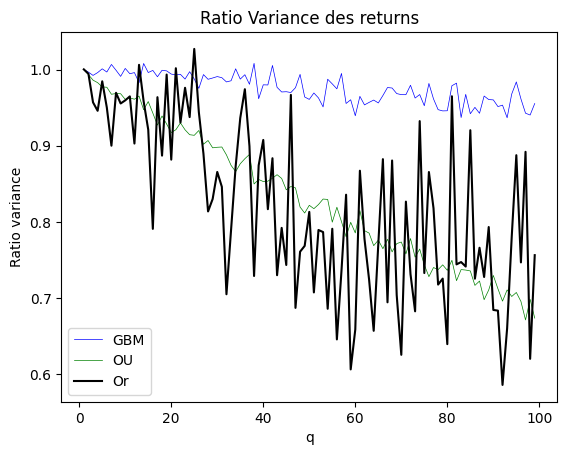

In [339]:
VR_GBM = np.zeros(100)
VR_OU = np.zeros(100)

for k in range(0,50) :
    GBM = [1]
    OU = [1]
    for i in range(1,len(prices)) :
        GBM.append(GBM[i-1]*np.exp((mu - sigma**2/2)*dt + sigma*np.sqrt(dt)*random.gauss(0,1)))
        OU.append(OU[i-1] + kappa*(theta - OU[i-1])*dt + np.sqrt(dt)*sigma*random.gauss(0,1))
    returns_GBM = [np.log(GBM[k+1]) - np.log(GBM[k]) for k in range (0, len(GBM) - 1)]
    returns_OU = [(OU[k+1] - OU[k])/OU[k] for k in range (0, len(GBM) - 1)]
    for q in range(1,100) :
        VR_GBM[q] = VR_GBM[q] + variance_ratio(q,returns_GBM)
        VR_OU[q] = VR_OU[q] + variance_ratio(q,returns_OU)

VR_GBM = [VR_GBM[q]/50 for q in range(1,100)]
VR_OU = [VR_OU[q]/50 for q in range(1,100)]

plt.plot(X, VR_GBM, color = 'blue', label = 'GBM', lw = 0.5)
plt.plot(X, VR_OU, color = 'green', label = 'OU', lw = 0.5)
plt.plot(X, VR_or, color = 'black', label = 'Or')
plt.title('Ratio Variance des returns')
plt.xlabel('q')
plt.ylabel('Ratio variance')
plt.legend()
plt.show()


Faire tourner 50 simulations est un peu long, mais cela permet des résultats consistants. Cette fois-ci, bien que l'on ne puisse pas tirer de conclusion extrêmement claire, le comportement du cours de l'or est plus proche du OU que du GBM.\

## 5) Conclusion

En conclusion, le cours de l'or a tout de même des comportements proches du GBM, surtout en ce qu'il a tendance à évoluer indépendamment de son passé.\
En revanche, le test de ratio de variance suggère une mean-reversion dans la structure de sa variance à long terme, caractéristique d'un processus OU. L'or n'est donc ni purement un actif d'investissement, ni purement une commodity, il emprunte aux deux, ce qui en fait un actif singulier